# Analyse du Data Drift

Ce notebook présente une analyse simple de la dérive des données entre un jeu de données de référence (entraînement) et les données de production collectées par l'API.

Les graphiques générés permettent de visualiser les différences de distribution entre les deux ensembles de données.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path("..").resolve()

LOG_FILE = BASE_DIR / "logs" / "predictions.jsonl"

REPORT_DIR = BASE_DIR / "reports"

REPORT_DIR.mkdir(exist_ok=True)

In [3]:
reference_data = pd.DataFrame({
    "AMT_CREDIT": [500000, 300000, 700000, 450000, 600000],
    "AMT_INCOME_TOTAL": [200000, 150000, 250000, 180000, 220000],
})

reference_data

,AMT_CREDIT,AMT_INCOME_TOTAL
0,500000,200000
1,300000,150000
2,700000,250000
3,450000,180000
4,600000,220000


In [4]:
logs = []

with open(LOG_FILE, "r", encoding="utf-8") as f:
    for line in f:
        logs.append(json.loads(line))

len(logs)

2

In [5]:
prod_rows = []

for log in logs:
    prod_rows.append(log["input"])

current_data = pd.DataFrame(prod_rows)

current_data

,AMT_CREDIT,AMT_INCOME_TOTAL,AMT_ANNUITY,DAYS_BIRTH,DAYS_EMPLOYED
0,500000,50000,5000,-16000,-500
1,200000,150000,25000,-12000,-2500


In [6]:
common_columns = [
    col for col in reference_data.columns
    if col in current_data.columns
]

common_columns

['AMT_CREDIT', 'AMT_INCOME_TOTAL']

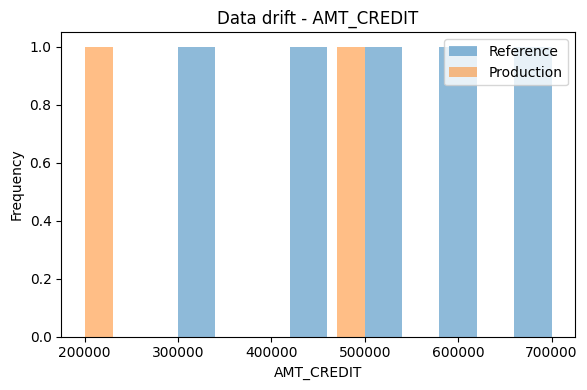

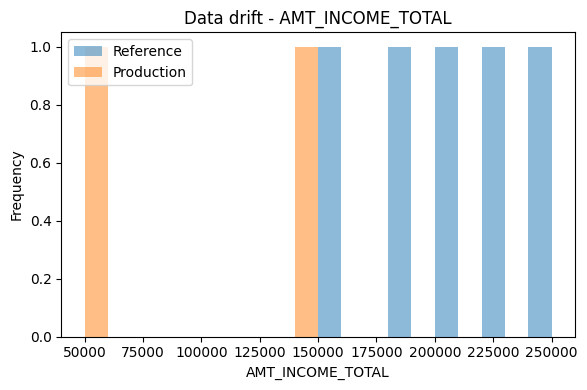

In [7]:
for column in common_columns:
    plt.figure(figsize=(6, 4))
    plt.hist(reference_data[column], alpha=0.5, label="Reference")
    plt.hist(current_data[column], alpha=0.5, label="Production")
    plt.title(f"Data drift - {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
print("===== Drift Analysis =====")

for col in common_columns:
    reference_mean = reference_data[col].mean()
    production_mean = current_data[col].mean()
    drift = abs(production_mean - reference_mean)

    print(
        f"{col}: "
        f"reference={reference_mean:.2f} "
        f"production={production_mean:.2f} "
        f"drift={drift:.2f}"
    )

    if drift > reference_data[col].std():
        print(f"ALERTE DRIFT : {col}")

===== Drift Analysis =====
AMT_CREDIT: reference=510000.00 production=350000.00 drift=160000.00
ALERTE DRIFT : AMT_CREDIT
AMT_INCOME_TOTAL: reference=200000.00 production=100000.00 drift=100000.00
ALERTE DRIFT : AMT_INCOME_TOTAL
